In [8]:
!pip install tensorboard

SyntaxError: invalid syntax (1728078699.py, line 1)

In [7]:
import os
# check common locations
for path in ['runs/', os.path.expanduser('~/scratch/runs/'), os.path.expanduser('~/weaver-core-dev/runs/')]:
    if os.path.exists(path):
        print(path, os.listdir(path))

runs/ ['Apr07_12-27-25_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr07_22-57-51_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr07_23-19-08_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_15-05-20_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_15-38-00_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_16-36-47_gpu2709.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_16-53-57_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_17-22-36_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Apr08_22-06-10_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon']


In [8]:
import tensorboard
from tensorboard.backend.event_processing import event_accumulator
ea = event_accumulator.EventAccumulator('runs/Apr08_22-06-10_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon')
ea.Reload()
print(ea.Tags())

{'images': [], 'audio': [], 'histograms': [], 'scalars': ['Loss/train', 'LossReg/train', 'Acc/train', 'LossRegSplit/train', 'LossRegUnifd/train', 'Loss/train (epoch)', 'LossReg/train (epoch)', 'LossTot/train (epoch)', 'Acc/train (epoch)', 'LossRegSplit/train (epoch)', 'LossRegUnifd/train (epoch)', 'Loss/eval (epoch)', 'LossReg/eval (epoch)', 'LossTot/eval (epoch)', 'Acc/eval (epoch)', 'LossRegSplit/eval (epoch)', 'LossRegUnifd/eval (epoch)', 'Loss/test (epoch)', 'LossReg/test (epoch)', 'LossTot/test (epoch)', 'Acc/test (epoch)', 'LossReg0/test (epoch)', 'LossReg1/test (epoch)'], 'distributions': [], 'tensors': [], 'graph': False, 'meta_graph': False, 'run_metadata': []}


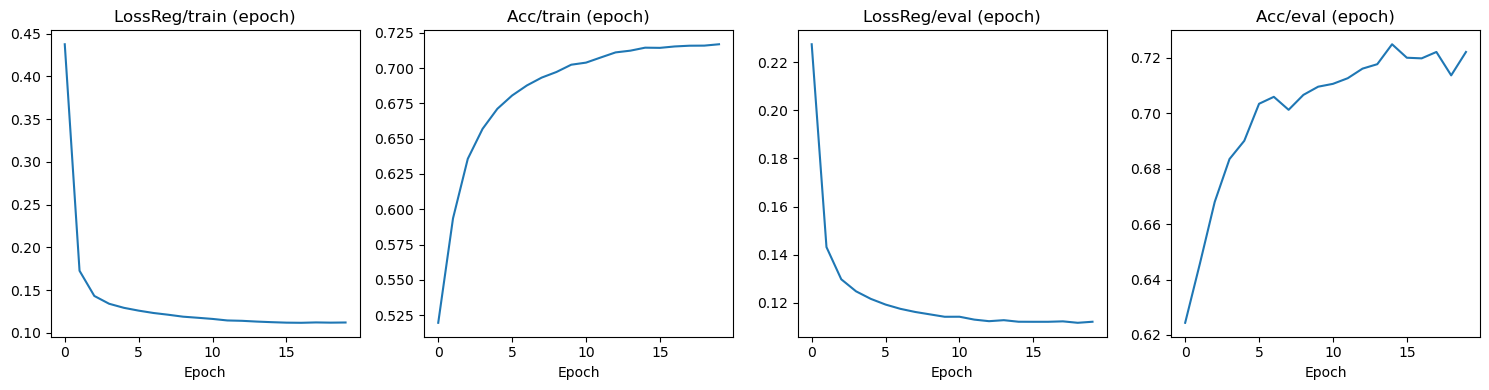

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, tag in zip(axes, ['LossReg/train (epoch)', 'Acc/train (epoch)', 'LossReg/eval (epoch)', 'Acc/eval (epoch)'] ):
    try:
        scalars = ea.Scalars(tag)
        steps = [s.step for s in scalars]
        values = [s.value for s in scalars]
        ax.plot(steps, values)
        ax.set_title(tag)
        ax.set_xlabel('Epoch')
    except:
        print(f'{tag} not found')

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

In [10]:
print(ea.Scalars("Acc/test (epoch)")[0].value)
print(ea.Scalars("Loss/test (epoch)")[0].value)

0.4755949378013611
0.0
